# COMP258 Group Project - Persistence Model 



In [2]:

import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:

# Robust dataset path handling
possible_paths = [
    Path("./Student data.csv"),
    Path("../Student data.csv"),
    Path("/mnt/data/Student data.csv"),
]

dataset_path = next((p for p in possible_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Could not find 'Student data.csv'. Place it beside the notebook or update dataset_path."
    )

data = pd.read_csv(dataset_path, skiprows=24, header=None, na_values="?")
print(f"Loaded dataset from: {dataset_path.resolve()}")
print(f"Raw shape: {data.shape}")


Loaded dataset from: C:\Users\royia\OneDrive\Desktop\Neural Network\student-success-predictor\data\ml-model\Student data.csv
Raw shape: (1437, 15)


In [4]:

columns = [
    "First_Term_GPA", "Second_Term_GPA", "First_Language", "Funding",
    "School", "FastTrack", "Coop", "Residency", "Gender",
    "Prev_Education", "Age_Group", "HS_Average", "Math_Score",
    "English_Grade", "FirstYearPersistence",
]

data.columns = columns
data.replace("?", pd.NA, inplace=True)

total_rows = len(data)
missing_summary = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Total Rows": total_rows,
    "Percentage Missing": (data.isnull().sum() / total_rows) * 100,
})

print("Total rows:", total_rows)
missing_summary


Total rows: 1437


,Missing Values,Total Rows,Percentage Missing
First_Term_GPA,17,1437,1.183020
Second_Term_GPA,160,1437,11.134308
First_Language,111,1437,7.724426
Funding,0,1437,0.000000
School,0,1437,0.000000
FastTrack,0,1437,0.000000
Coop,0,1437,0.000000
Residency,0,1437,0.000000
Gender,0,1437,0.000000
Prev_Education,4,1437,0.278358


In [5]:

numeric_columns = ["First_Term_GPA", "Second_Term_GPA", "HS_Average", "Math_Score"]
categorical_columns = [
    "First_Language", "Funding", "School", "FastTrack", "Coop",
    "Residency", "Gender", "Prev_Education", "Age_Group", "English_Grade"
]
one_hot_columns = [
    "First_Language", "Funding", "School", "Gender",
    "Prev_Education", "Age_Group", "English_Grade"
]
passthrough_binary_columns = [col for col in categorical_columns if col not in one_hot_columns]

# Convert numeric columns safely
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Convert target to numeric binary labels
data["FirstYearPersistence"] = pd.to_numeric(data["FirstYearPersistence"], errors="coerce")

# Keep only rows with a valid binary target
data = data[data["FirstYearPersistence"].isin([0, 1])].copy()
data["FirstYearPersistence"] = data["FirstYearPersistence"].astype(int)

print("Filtered shape:", data.shape)
print(data["FirstYearPersistence"].value_counts(dropna=False))


Filtered shape: (1437, 15)
FirstYearPersistence
1    1138
0     299
Name: count, dtype: int64


In [6]:

y = data["FirstYearPersistence"]
X = data.drop(columns=["FirstYearPersistence"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, one_hot_columns),
        ("bin", "passthrough", passthrough_binary_columns),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to dense for Keras if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

input_shape = X_train_processed.shape[1]
print("Number of features after preprocessing:", input_shape)


Number of features after preprocessing: 38


In [7]:

model = Sequential([
    Input(shape=(input_shape,)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7563 - loss: 0.5661 - val_accuracy: 0.8087 - val_loss: 0.4530
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7998 - loss: 0.4698 - val_accuracy: 0.8217 - val_loss: 0.4068
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8128 - loss: 0.4275 - val_accuracy: 0.8478 - val_loss: 0.3946
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8215 - loss: 0.4102 - val_accuracy: 0.8522 - val_loss: 0.3871
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8455 - loss: 0.3893 - val_accuracy: 0.8522 - val_loss: 0.3837
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8270 - loss: 0.3948 - val_accuracy: 0.8522 - val_loss: 0.3805
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8455 - loss: 0.3806 - val_accuracy: 0.8565 - val_loss: 0.3802
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8607 - loss: 0.3821 - val_accuracy: 0.8478 - val_loss:

In [8]:

loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

y_pred_prob = model.predict(X_test_processed, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Loss: 0.3954230546951294
Test Accuracy: 0.8402777910232544

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.37      0.49        60
           1       0.85      0.96      0.91       228

    accuracy                           0.84       288
   macro avg       0.79      0.67      0.70       288
weighted avg       0.83      0.84      0.82       288



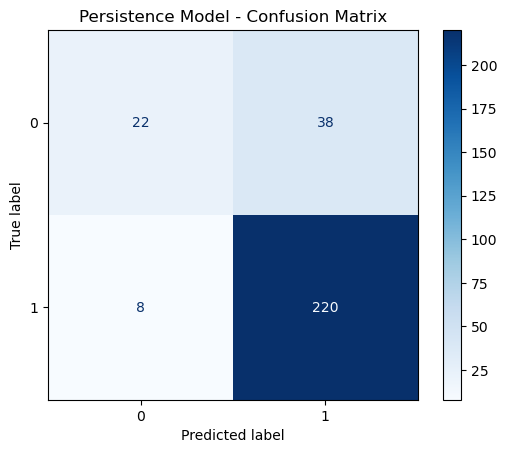

In [9]:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Persistence Model - Confusion Matrix")
plt.show()


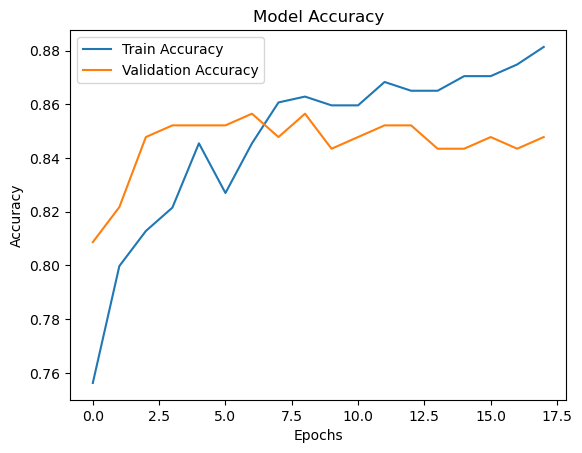

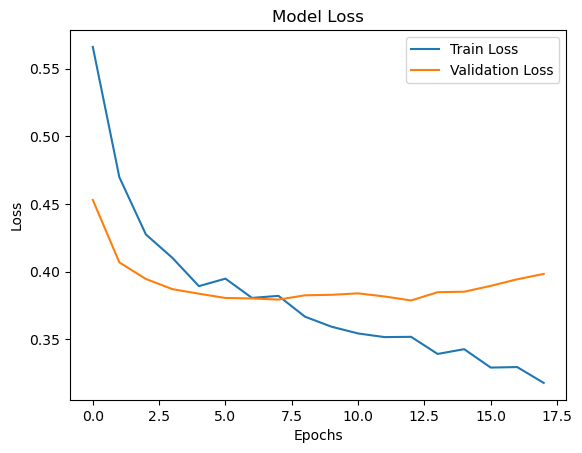

In [10]:

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [11]:

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

preprocessor_path = output_dir / "persistence_preprocessor.pkl"
model_path = output_dir / "persistence_model.h5"

joblib.dump(preprocessor, preprocessor_path)
model.save(model_path)

print(f"Saved preprocessor to: {preprocessor_path.resolve()}")
print(f"Saved model to: {model_path.resolve()}")


Saved preprocessor to: C:\Users\royia\OneDrive\Desktop\Neural Network\student-success-predictor\data\ml-model\output\persistence_preprocessor.pkl
Saved model to: C:\Users\royia\OneDrive\Desktop\Neural Network\student-success-predictor\data\ml-model\output\persistence_model.h5
